<h1 style="color:purple;">Entrenamiento de CNN con LINEX Function en su función de pérdida siguiendo a Chao.</h1>
<p> Valentina Arce España <p>
<p> Febrero 17, 2026 <p>

<div class="alert alert-block alert-warning">
Aplicamos la misma metodología de la versión 2 pero con una CNN distinta.

Cargando datos...
Reduciendo dataset de entrenamiento: Usando 2 de 9 motores.
Forma de X_train (reducido): (1060535, 32)
Generando ventanas (Step=10)...
Input Shape Train Final: (106045, 50, 32)
Input Shape Test Final: (372274, 50, 32)


/opt/miniconda3/envs/tesis_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 50, 10)         │           970 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 50, 10)         │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 50, 10)         │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 50, 10)         │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 50, 1)          │            31 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,532 (17.70 KB)

 Trainable params: 4,532 (17.70 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - loss: 576.3992 - val_loss: 687.7137
Epoch 2/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 201.3672 - val_loss: 59.1718
Epoch 3/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 83.3774 - val_loss: 26.3436
Epoch 4/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 70.8985 - val_loss: 25.9102
Epoch 5/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - loss: 59.9889 - val_loss: 22.7457
Epoch 6/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - loss: 50.4840 - val_loss: 21.2248
Epoch 7/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 44.6404 - val_loss: 21.8911
Epoch 8/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - loss: 39.6070 - val_loss: 23.6212
Epoch 9/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: 35.6947 - val_loss: 23.3439
Epoch 10/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - loss: 31.4746 - val_loss: 15.9450
Epoch 11/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - loss: 29.4139 - val_loss: 12.3696
Epoch 12/15
1

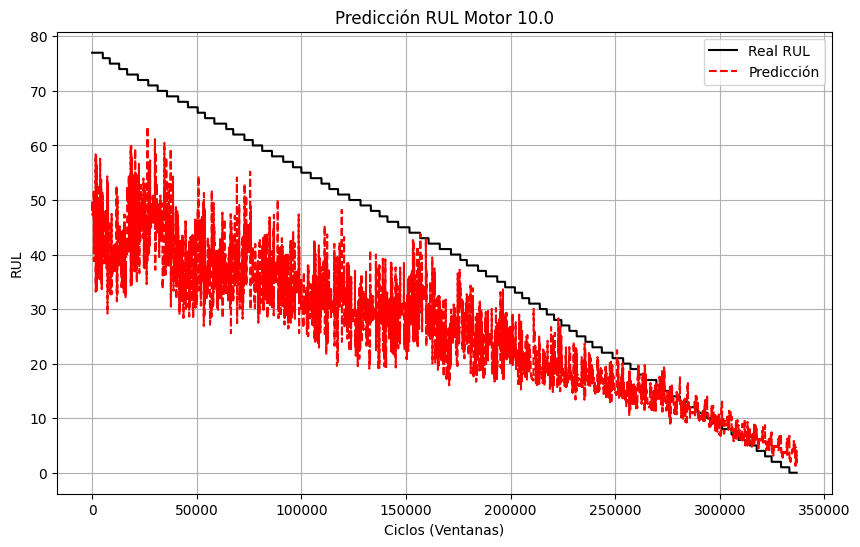

In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers, models

# ==========================================
# 1. CONFIGURACIÓN (MODO AHORRO DE MEMORIA)
# ==========================================
filename = 'N-CMAPSS_DS08a-009.h5' 
WINDOW_SIZE = 50   
BATCH_SIZE = 512
EPOCHS = 15

# --- PARÁMETROS DE REDUCCIÓN ---
# Usar solo el 30% de los motores disponibles para entrenar (0.1 = 10%, 1.0 = 100%)
TRAIN_RATIO = 0.3  

# Salto al crear ventanas (Downsampling). 
# 1 = toma todas las ventanas posibles (máxima memoria).
# 10 = toma 1 ventana cada 10 segundos. Reduce el tamaño del dataset en 10x.
WINDOW_STEP = 10  

def load_data(filepath):
    with h5py.File(filepath, 'r') as hdf:
        # Development set (Train)
        W_dev = np.array(hdf.get('W_dev'))
        X_s_dev = np.array(hdf.get('X_s_dev'))
        X_v_dev = np.array(hdf.get('X_v_dev'))
        Y_dev = np.array(hdf.get('Y_dev'))
        A_dev = np.array(hdf.get('A_dev')) 
        
        # Test set
        W_test = np.array(hdf.get('W_test'))
        X_s_test = np.array(hdf.get('X_s_test'))
        X_v_test = np.array(hdf.get('X_v_test'))
        Y_test = np.array(hdf.get('Y_test'))
        A_test = np.array(hdf.get('A_test'))
        
        # Corrección de lectura de variables
        A_var = np.array(hdf.get('A_var'))
        A_var = list(np.array(A_var, dtype='U20'))
        
    return (W_dev, X_s_dev, X_v_dev, Y_dev, A_dev), (W_test, X_s_test, X_v_test, Y_test, A_test), A_var

print("Cargando datos...")
(train_W, train_Xs, train_Xv, train_Y, train_A), \
(test_W, test_Xs, test_Xv, test_Y, test_A), A_var = load_data(filename)

# ==========================================
# 2. REDUCCIÓN DE MOTORES (TRAIN)
# ==========================================
# Identificar unidades únicas en entrenamiento
train_units = np.unique(train_A[:, 0])
n_units_original = len(train_units)
n_units_keep = int(n_units_original * TRAIN_RATIO)

# Seleccionar solo las primeras N unidades
keep_units = train_units[:n_units_keep]

print(f"Reduciendo dataset de entrenamiento: Usando {n_units_keep} de {n_units_original} motores.")

# Filtrar los arrays de entrenamiento
# Buscamos los índices donde la columna unit (0) esté en nuestra lista keep_units
mask_train = np.isin(train_A[:, 0], keep_units)

train_W = train_W[mask_train]
train_Xs = train_Xs[mask_train]
train_Xv = train_Xv[mask_train]
train_Y = train_Y[mask_train]
train_A = train_A[mask_train]

# ==========================================
# 3. PREPROCESAMIENTO Y ESCALADO
# ==========================================
X_train = np.concatenate((train_W, train_Xs, train_Xv), axis=1)
X_test = np.concatenate((test_W, test_Xs, test_Xv), axis=1)

scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Forma de X_train (reducido): {X_train_scaled.shape}")

# ==========================================
# 4. GENERACIÓN DE VENTANAS CON SALTO (STEP)
# ==========================================
def create_windows(X, y, A, window_size, step=1, unit_col_index=0):
    unique_units = np.unique(A[:, unit_col_index])
    X_windows = []
    y_windows = []
    
    for unit in unique_units:
        idx = np.where(A[:, unit_col_index] == unit)[0]
        unit_X = X[idx, :]
        unit_y = y[idx]
        
        num_samples = len(unit_X)
        if num_samples < window_size:
            continue
            
        # APLICAMOS EL STEP AQUÍ PARA REDUCIR DATOS
        for i in range(0, num_samples - window_size + 1, step):
            X_windows.append(unit_X[i : i + window_size, :])
            y_windows.append(unit_y[i + window_size - 1])
            
    return np.array(X_windows), np.array(y_windows)

print(f"Generando ventanas (Step={WINDOW_STEP})...")
# Entrenamos con salto para ahorrar memoria
X_train_w, y_train_w = create_windows(X_train_scaled, train_Y, train_A, WINDOW_SIZE, step=WINDOW_STEP)

# Para test, generalmente queremos evaluar todo, pero si falla memoria, aumenta el step aquí también
X_test_w, y_test_w = create_windows(X_test_scaled, test_Y, test_A, WINDOW_SIZE, step=10) 

print(f"Input Shape Train Final: {X_train_w.shape}")
print(f"Input Shape Test Final: {X_test_w.shape}")

# ==========================================
# 5. MODELO CNN
# ==========================================
input_shape = (X_train_w.shape[1], X_train_w.shape[2])

# ==========================================
# MODELO CNN REPLICANDO A CHAO ET AL. (2022)
# ==========================================
model_chao = models.Sequential([
    # Capa 1 a 4: 10 filtros, kernel 3, ReLU, padding same
    layers.Conv1D(filters=10, kernel_size=3, activation='relu', padding='same', input_shape=input_shape),
    layers.Conv1D(filters=10, kernel_size=3, activation='relu', padding='same'),
    layers.Conv1D(filters=10, kernel_size=3, activation='relu', padding='same'),
    layers.Conv1D(filters=10, kernel_size=3, activation='relu', padding='same'),
    
    # Capa 5: Reduce a 1 solo filtro
    layers.Conv1D(filters=1, kernel_size=3, activation='relu', padding='same'),
    
    # Parte densa
    layers.Flatten(),
    layers.Dense(50, activation='relu'),
    layers.Dense(1) # Salida RUL
])

model_chao.compile(optimizer='adam', loss='mse')
model_chao.summary()

# ==========================================
# 6. ENTRENAMIENTO
# ==========================================
history = model_chao.fit(
    X_train_w, y_train_w,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

# ==========================================
# 7. EVALUACIÓN
# ==========================================
print("Prediciendo...")
y_pred = model_chao.predict(X_test_w)
rmse = np.sqrt(mean_squared_error(y_test_w, y_pred))
print(f"\nRMSE Global en Test: {rmse:.4f}")

# Visualización (Primer motor del test)
test_units = np.unique(test_A[:, 0])
target_unit = test_units[0]
idx_unit = np.where(test_A[:, 0] == target_unit)[0]

# Extraemos solo datos de ese motor para graficar limpio
unit_X_scaled = X_test_scaled[idx_unit]
unit_y_raw = test_Y[idx_unit]
# Usamos step=1 aquí para tener la gráfica bonita y suave, aunque tarde un poco más en predecir
X_unit_w, y_unit_w = create_windows(unit_X_scaled, unit_y_raw, test_A[idx_unit], WINDOW_SIZE, step=1)
y_unit_pred = model_chao.predict(X_unit_w)

plt.figure(figsize=(10, 6))
plt.plot(y_unit_w, label='Real RUL', color='black')
plt.plot(y_unit_pred, label='Predicción', color='red', linestyle='--')
plt.title(f'Predicción RUL Motor {target_unit}')
plt.xlabel('Ciclos (Ventanas)')
plt.ylabel('RUL')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
import tensorflow.keras.backend as K

# --- PASO 1: DEFINIR LA FUNCIÓN LINEX ---
def linex_loss(y_true, y_pred):
    a = -0.1  # Penalización para predicciones tardías
    error = y_true - y_pred
    loss = K.exp(a * error) - (a * error) - 1
    return K.mean(loss)

In [4]:
# --- PASO 2: CREAR LA COPIA (CLONAR EL MODELO ENTRENADO) ---
# Primero guardamos el modelo actual (MSE) en disco por seguridad
model_chao.save('modelo_mse_Chao.keras')

In [5]:
# Luego lo cargamos en una NUEVA variable llamada 'model_linex'
# (Esto es lo que te faltaba: "llamar al modelo")
model_linex = load_model('modelo_mse_Chao.keras')

In [6]:
# --- PASO 3: RE-ENTRENAR CON LINEX (FINE-TUNING) ---
print("Compilando con LINEX...")

# Usamos un learning rate bajito (0.0001) para no dañar los pesos que ya aprendió
model_linex.compile(optimizer=Adam(learning_rate=0.0001), loss=linex_loss)

print("Iniciando Fine-Tuning con LINEX...")
history_linex = model_linex.fit(
    X_train_w, y_train_w,
    epochs=10, 
    batch_size=512,
    validation_split=0.1,
    verbose=1
)

print("¡Entrenamiento LINEX finalizado!")

Compilando con LINEX...
Iniciando Fine-Tuning con LINEX...
Epoch 1/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - loss: 0.0919 - val_loss: 0.0430
Epoch 2/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 0.0898 - val_loss: 0.0445
Epoch 3/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 0.0885 - val_loss: 0.0423
Epoch 4/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - loss: 0.0875 - val_loss: 0.0399
Epoch 5/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 0.0865 - val_loss: 0.0397
Epoch 6/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - loss: 0.0855 - val_loss: 0.0373
Epoch 7/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.0844 - val_loss: 0.0341
Epoch 8/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 0.0836 - val_loss: 0.0342
Epoch 9/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - loss: 0.0821 - val_loss: 0.0321
Epoch 10/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - loss: 0.0821 - val_loss: 0.0305
¡Entrenamiento LINEX finalizado!


In [7]:
# Evaluar ambos modelos en el set de test completo
y_pred_mse = model_chao.predict(X_test_w, verbose=0)
y_pred_linex = model_linex.predict(X_test_w, verbose=0)

rmse_mse = np.sqrt(mean_squared_error(y_test_w, y_pred_mse))
rmse_linex = np.sqrt(mean_squared_error(y_test_w, y_pred_linex))

# Calcular el error promedio (Bias)
# Un error positivo significa que el modelo es conservador (predice RUL menor al real)
bias_mse = np.mean(y_test_w - y_pred_mse)
bias_linex = np.mean(y_test_w - y_pred_linex)

print(f"--- COMPARATIVA FINAL ---")
print(f"MSE Model   | RMSE: {rmse_mse:.4f} | Bias: {bias_mse:.4f}")
print(f"LINEX Model | RMSE: {rmse_linex:.4f} | Bias: {bias_linex:.4f}")

--- COMPARATIVA FINAL ---
MSE Model   | RMSE: 8.7326 | Bias: -1.6893
LINEX Model | RMSE: 8.4510 | Bias: 0.5888


Generando comparativa para el Motor 13...


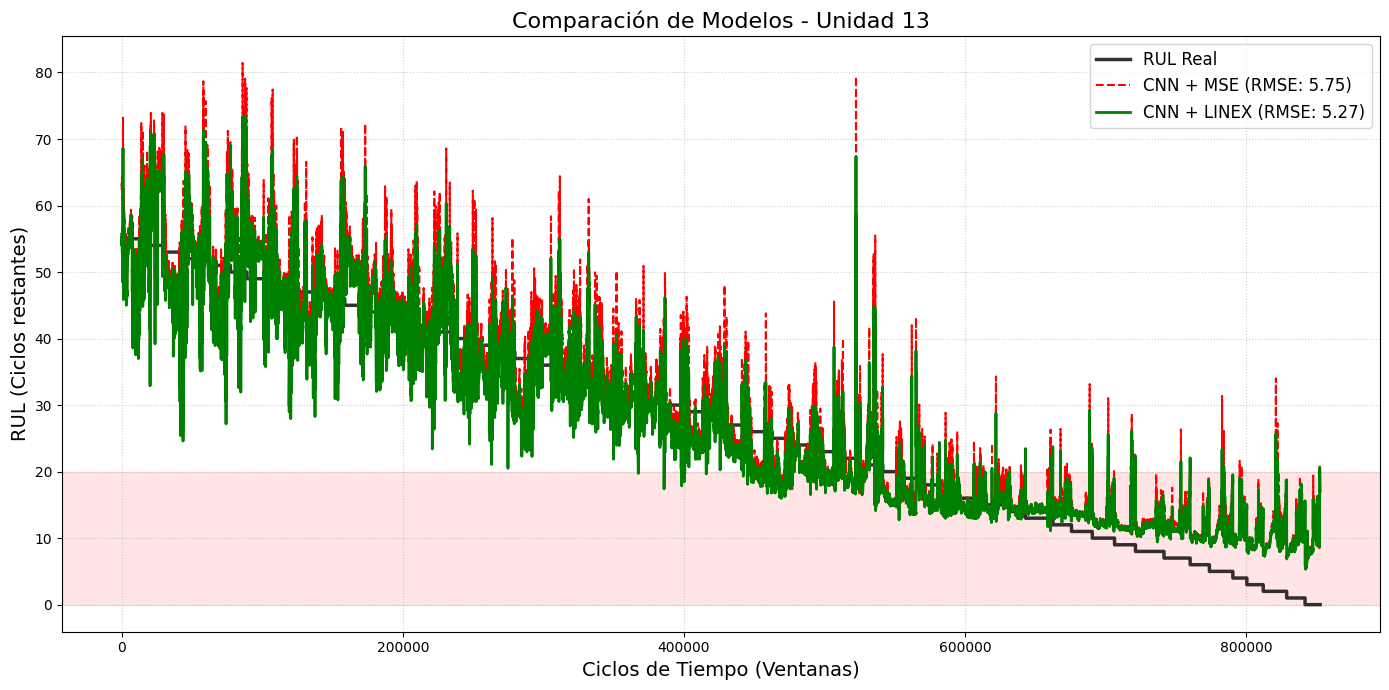

In [8]:
def comparar_resultados_motores(unit_id):
    """
    Grafica la comparación entre el modelo MSE (Original) y el modelo LINEX (Refinado)
    para una unidad específica del set de test.
    """
    print(f"Generando comparativa para el Motor {unit_id}...")
    
    # 1. Filtrar datos de la unidad elegida
    idx = np.where(test_A[:, 0] == unit_id)[0]
    
    if len(idx) == 0:
        print(f"Error: El motor {unit_id} no se encuentra en el set de Test.")
        return

    # 2. Extraer y preparar ventanas (paso 1 para máxima resolución)
    unit_X = X_test_scaled[idx]
    unit_y = test_Y[idx]
    
    # Reutilizamos la función create_windows que definimos antes
    X_w, y_real = create_windows(unit_X, unit_y, test_A[idx], WINDOW_SIZE, step=1)
    
    # 3. Realizar predicciones con ambos modelos
    # 'model_chao' es el de MSE y 'model_linex' es el de LINEX
    pred_mse = model_chao.predict(X_w, verbose=0)
    pred_linex = model_linex.predict(X_w, verbose=0)
    
    # 4. Calcular RMSE individual para el reporte en el título
    rmse_mse = np.sqrt(mean_squared_error(y_real, pred_mse))
    rmse_linex = np.sqrt(mean_squared_error(y_real, pred_linex))
    
    # 5. GRAFICAR
    plt.figure(figsize=(14, 7))
    
    # Línea Real
    plt.plot(y_real, label='RUL Real', color='black', linewidth=2.5, alpha=0.8)
    
    # Predicción MSE
    plt.plot(pred_mse, label=f'CNN + MSE (RMSE: {rmse_mse:.2f})', 
             color='red', linestyle='--', linewidth=1.5)
    
    # Predicción LINEX
    plt.plot(pred_linex, label=f'CNN + LINEX (RMSE: {rmse_linex:.2f})', 
             color='green', linewidth=2)
    
    # Estética de la gráfica
    plt.title(f'Comparación de Modelos - Unidad {unit_id}', fontsize=16)
    plt.xlabel('Ciclos de Tiempo (Ventanas)', fontsize=14)
    plt.ylabel('RUL (Ciclos restantes)', fontsize=14)
    plt.legend(loc='upper right', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Añadir una zona de "Falla Crítica" sombreada para mayor impacto visual
    plt.axhspan(0, 20, color='red', alpha=0.1, label='Zona Crítica')
    
    plt.tight_layout()
    plt.show()

# --- Ejecución para el motor 13 ---
comparar_resultados_motores(13)

# También puedes probar con otros motores rápidamente:
# comparar_resultados_motores(14)
# comparar_resultados_motores(15)

In [ ]:
model_linex.save('modelo_mse_Chao_Linex.keras')